# Tutorial Notebook: XAI Warm-Up (Professional Model Audit)

This tutorial is a complete reference pipeline before the project workbook.

You will practice: focused EDA, leakage-safe splitting, black-box model training, local explanations (SHAP + LIME), global dependency checks, and subgroup slicing.

How to use this notebook: run cells in order, read the notes before each block, and write one short audit takeaway after each section.

## 1) Audit Framing

Before modeling, define the audit objective:

- Objective: build a strong default-risk predictor and audit its behavior
- Decision: identify risky applications for manual review
- Required evidence: performance metrics + explanation evidence + subgroup failure analysis

Interpretation rule: high AUC alone is not enough for decision trust.

In [38]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# XAI and model libraries are installed in the pDL environment.
import shap
from lime.lime_tabular import LimeTabularExplainer
from lightgbm import LGBMClassifier

In [39]:
def make_model(seed):
    # Gradient-boosted trees usually provide strong tabular baseline performance.
    return LGBMClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=seed
    )

RANDOM_SEED = 42
MODEL_NAME = 'LightGBM'
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)

print('Model backend:', MODEL_NAME)

Model backend: LightGBM


## 2) Load Data

This tutorial uses a fixed simple dataset located at ./data/subscription_churn.csv.

Target column: churned (1 = churn risk, 0 = retained).

Using a fixed local dataset keeps this notebook reproducible and avoids setup noise.

In [ ]:
# Use a fixed local dataset so every student gets identical results.
DATA_DIR = Path('data')
DATA_FILE = DATA_DIR / 'subscription_churn.csv'

if not DATA_FILE.exists():
    raise FileNotFoundError(f'Required file not found: {DATA_FILE}')

# Load raw table exactly once; all later transformations start from this frame.
df_raw = pd.read_csv(DATA_FILE)
print('Using data file:', DATA_FILE)
print('Shape:', df_raw.shape)
display(df_raw.head(2))

Using data file: data/subscription_churn.csv
Shape: (180, 10)


,customer_id,age,tenure_months,monthly_spend,num_logins,support_tickets,plan_type,region,auto_pay,churned
0,C0001,59,43,47,83,7,basic,pacific,1,0
1,C0002,57,51,102,64,0,enterprise,pacific,1,0


## 3) Define Target and Basic Cleaning

We auto-detect common binary target columns. If target is string status labels, we map risky outcomes to 1.

Leakage warning: remove columns that directly reveal outcome timing or post-decision events.

In [ ]:
# Work on a copy to keep the original raw data intact.
df = df_raw.copy()

if 'churned' not in df.columns:
    raise ValueError("Expected target column 'churned' in subscription_churn.csv")

target_col = 'churned'
# Convert target to numeric 0/1 in case the CSV has mixed types.
y = pd.to_numeric(df[target_col], errors='coerce').fillna(0).astype(int)

# Drop identifiers and target label from features to avoid leakage.
drop_cols = {target_col, 'customer_id'}
feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].copy()

print('Target column:', target_col)
print('Positive rate:', round(float(y.mean()), 4))
print('Feature count:', X.shape[1])
display(X.head(2))

Target column: churned
Positive rate: 0.3556
Feature count: 8


,age,tenure_months,monthly_spend,num_logins,support_tickets,plan_type,region,auto_pay
0,59,43,47,83,7,basic,pacific,1
1,57,51,102,64,0,enterprise,pacific,1


## 4) Split Data (Train / Validation / Test)

- Train: fit preprocessing and model
- Validation: choose threshold and inspect failures
- Test: one-time final estimate

Use stratified splits to preserve positive class rate.

In [ ]:
# First split: hold out test data for final one-time evaluation.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)
# Second split: carve validation out of training pool for model diagnostics.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_SEED, stratify=y_train_val
)

print('Train size:', len(X_train))
print('Val size:  ', len(X_val))
print('Test size: ', len(X_test))
print('Positive rate train/val/test:', round(y_train.mean(),4), round(y_val.mean(),4), round(y_test.mean(),4))

Train size: 108
Val size:   36
Test size:  36
Positive rate train/val/test: 0.3519 0.3611 0.3611


## 5) Quick EDA for Audit Context

Inspect class balance and top missingness to understand reliability risks before training.

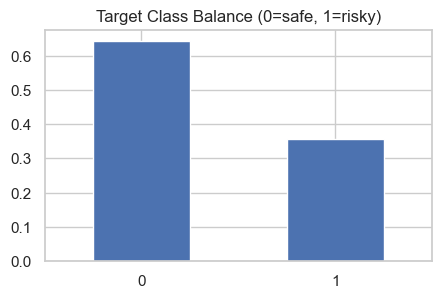

age                0.0
tenure_months      0.0
monthly_spend      0.0
num_logins         0.0
support_tickets    0.0
plan_type          0.0
region             0.0
auto_pay           0.0
Name: missing_percent, dtype: float64

In [ ]:
# Quick class-balance chart: helps interpret metrics like F1 and ROC-AUC.
plt.figure(figsize=(5, 3))
y.value_counts(normalize=True).sort_index().plot(kind='bar')
plt.title('Target Class Balance (0=safe, 1=risky)')
plt.xticks(rotation=0)
plt.show()

# Missingness snapshot guides imputation strategy in the preprocessing step.
missing = X.isna().mean().sort_values(ascending=False).head(15)
display((100 * missing).round(2).rename('missing_percent'))

## 6) Preprocess + Train Black-Box Model

We use median imputation for numeric columns and ordinal encoding for categoricals to keep the tutorial compact.

Note: ordinal encoding here is a practical tutorial choice, not a causal statement about category order.

In [40]:
# Separate features by type so preprocessing is explicit and reproducible.
numeric_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# Numeric path: median imputation; categorical path: frequent value + ordinal encoding.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), categorical_cols)
    ],
    remainder='drop'
)

# Fit preprocessing on training only, then transform validation/test.
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

feature_names = numeric_cols + categorical_cols

In [41]:
# Train model and compute validation probabilities for downstream analysis.
model = make_model(RANDOM_SEED)
model.fit(X_train_t, y_train)

# Probabilities are required for thresholding and explanation methods.
val_proba = model.predict_proba(X_val_t)[:, 1]
val_pred = (val_proba >= 0.5).astype(int)

print('Validation ROC-AUC:', round(roc_auc_score(y_val, val_proba), 4))
print('Validation F1 (0.5 threshold):', round(f1_score(y_val, val_pred), 4))

[LightGBM] [Info] Number of positive: 38, number of negative: 70
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 137
[LightGBM] [Info] Number of data points in the train set: 108, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.351852 -> initscore=-0.610909
[LightGBM] [Info] Start training from score -0.610909
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

## 7) Error Cases for Local Explanations

Pick concrete false positives and false negatives. In the project, you will explain at least 3 failures.

In [ ]:
# Store validation predictions for error analysis and local explanation selection.
val_results = pd.DataFrame({
    'y_true': y_val.values,
    'y_prob': val_proba,
    'y_pred': val_pred
}, index=X_val.index)

# False positives and false negatives are the key audit cases.
fp_idx = val_results[(val_results['y_true'] == 0) & (val_results['y_pred'] == 1)].index.tolist()
fn_idx = val_results[(val_results['y_true'] == 1) & (val_results['y_pred'] == 0)].index.tolist()

print('False positives:', len(fp_idx))
print('False negatives:', len(fn_idx))

display(val_results.head())

False positives: 11
False negatives: 7


,y_true,y_prob,y_pred
114,0,0.597134,1
86,1,0.012492,0
104,0,0.796748,1
56,0,0.031443,0
27,1,0.871281,1


## 8) SHAP: Global + Local

Global: which features drive risk overall?

Local: why was a specific case misclassified?

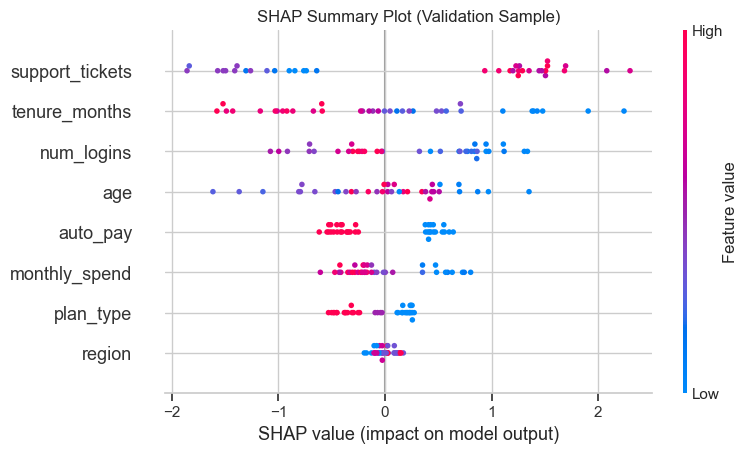

In [42]:
# Use a sample for SHAP speed while preserving a representative validation slice.
sample_n = min(1500, X_val_t.shape[0])
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(np.arange(X_val_t.shape[0]), size=sample_n, replace=False)
X_val_shap = X_val_t[sample_idx]

# Build SHAP explainer and compute global explanation values.
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val_shap)

# Handle both binary-class list output and array output from SHAP.
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_plot = shap_values

# Global view: feature influence distribution across many samples.
shap.summary_plot(shap_values_plot, X_val_shap, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot (Validation Sample)')
plt.tight_layout()
plt.show()

In [43]:
# Choose one misclassified case for local explanation.
if fp_idx:
    local_id = fp_idx[0]
elif fn_idx:
    local_id = fn_idx[0]
else:
    local_id = X_val.index[0]

local_pos = X_val.index.get_loc(local_id)
local_values = X_val_t[local_pos:local_pos + 1]
local_sv = explainer.shap_values(local_values)

print('Local case index:', local_id)
print('Predicted risk:', round(float(model.predict_proba(local_values)[:, 1][0]), 4))

if isinstance(local_sv, list):
    local_sv_plot = local_sv[1] if len(local_sv) > 1 else local_sv[0]
else:
    local_sv_plot = local_sv

# Show top local contributors ranked by absolute SHAP value.
shap_values_series = pd.Series(local_sv_plot[0], index=feature_names).sort_values(key=np.abs, ascending=False).head(10)
display(shap_values_series.rename('local_shap_contribution'))

Local case index: 114
Predicted risk: 0.5971


support_tickets    1.506604
monthly_spend      0.630962
auto_pay          -0.507039
num_logins        -0.441612
plan_type          0.225347
region             0.102388
age                0.086889
tenure_months     -0.063147
Name: local_shap_contribution, dtype: float64

## 9) LIME: Local Fidelity Check

LIME explains one prediction with a local surrogate model. Compare this view with SHAP for consistency checks.

LIME local case index: 114


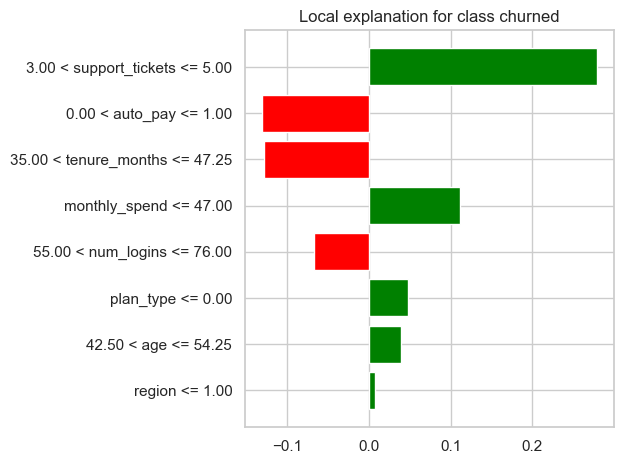

In [ ]:
# LIME builds a local surrogate model around one selected observation.
lime_explainer = LimeTabularExplainer(
    training_data=np.asarray(X_train_t),
    feature_names=feature_names,
    class_names=['retained', 'churned'],
    mode='classification',
    random_state=RANDOM_SEED
)

# Reuse the same error-case selection logic for SHAP/LIME comparability.
if fp_idx:
    local_id = fp_idx[0]
elif fn_idx:
    local_id = fn_idx[0]
else:
    local_id = X_val.index[0]

local_pos = X_val.index.get_loc(local_id)
exp = lime_explainer.explain_instance(
    data_row=np.asarray(X_val_t[local_pos]),
    predict_fn=model.predict_proba,
    num_features=10
)

print('LIME local case index:', local_id)
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

## 10) Global Explanation: Feature Importance

Use permutation importance on the validation set to estimate how much each feature contributes to predictive performance.

Why permutation importance: it works across model backends and is less tied to model internals than gain-based importance.

,feature,importance_mean,importance_std
4,support_tickets,0.124164,0.073511
7,region,-0.000418,0.006354
5,auto_pay,-0.001672,0.019644
6,plan_type,-0.011706,0.011464
0,age,-0.014214,0.042887
3,num_logins,-0.015886,0.048804
2,monthly_spend,-0.041806,0.023531
1,tenure_months,-0.081104,0.038850


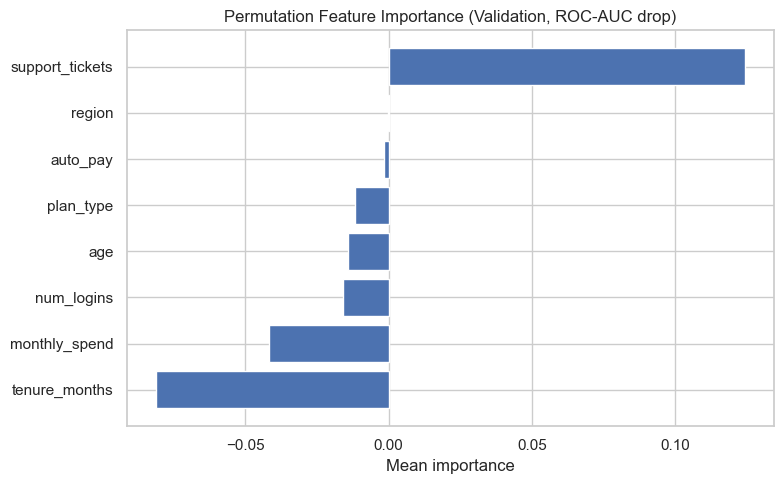

In [ ]:
# Permutation importance measures validation performance drop when a feature is shuffled.
perm = permutation_importance(
    estimator=model,
    X=X_val_t,
    y=y_val,
    n_repeats=8,
    random_state=RANDOM_SEED,
    scoring='roc_auc'
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

display(importance_df.head(15))

# Plot top features to make global ranking easy to interpret.
top_plot = importance_df.head(12).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top_plot['feature'], top_plot['importance_mean'])
plt.title('Permutation Feature Importance (Validation, ROC-AUC drop)')
plt.xlabel('Mean importance')
plt.tight_layout()
plt.show()

## 11) Global Explanation: PDP (Partial Dependence)

PDP shows the average marginal effect of a feature on predicted risk while averaging over the rest of the data.

Read carefully: PDP is descriptive, not causal.

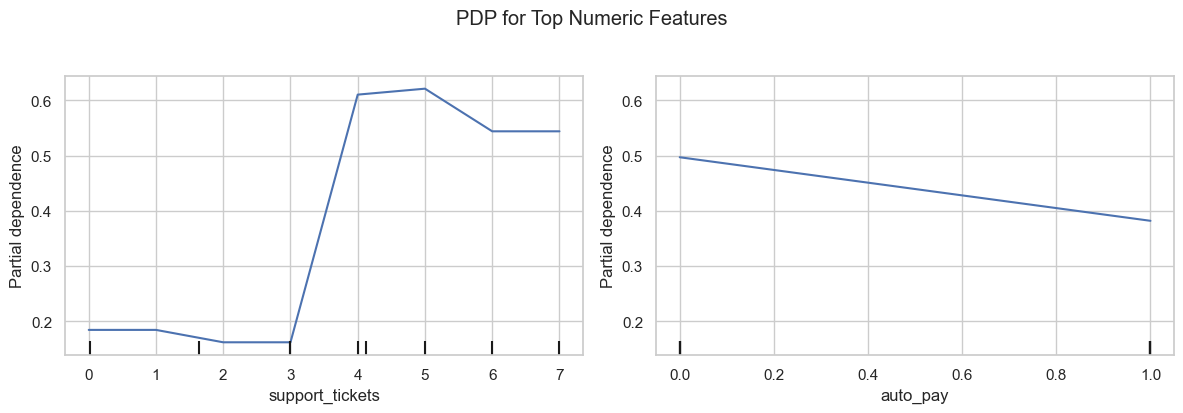

In [ ]:
# PDP is most interpretable on numeric features; choose top-ranked numeric drivers.
top_numeric = [f for f in importance_df['feature'].tolist() if f in numeric_cols]
if not top_numeric:
    print('No numeric features available for PDP in current preprocessing setup.')
else:
    pdp_features = top_numeric[:2]
    pdp_indices = [feature_names.index(f) for f in pdp_features]

    fig, ax = plt.subplots(1, len(pdp_indices), figsize=(6 * len(pdp_indices), 4))
    if len(pdp_indices) == 1:
        ax = [ax]

    # Each PDP curve shows average predicted risk as one feature varies.
    PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=X_val_t,
        features=pdp_indices,
        feature_names=feature_names,
        grid_resolution=25,
        ax=ax
    )
    plt.suptitle('PDP for Top Numeric Features', y=1.03)
    plt.tight_layout()
    plt.show()

## 12) Global Explanation: Interaction Effects

Interaction means the effect of Feature A depends on Feature B.

This section tries SHAP interaction values first. If unavailable, it falls back to a risk heatmap based on predicted probabilities.

In [44]:
# Test interaction between the two strongest global features.
top2 = importance_df['feature'].head(2).tolist()
interaction_ok = False
if len(top2) < 2:
    print('Need at least two features to analyze interactions.')
else:
    f1, f2 = top2[0], top2[1]
    i1, i2 = feature_names.index(f1), feature_names.index(f2)

    # Interaction values are expensive, so compute on a modest sample.
    inter_sample_n = min(600, X_val_t.shape[0])
    inter_idx = np.random.default_rng(RANDOM_SEED).choice(
        np.arange(X_val_t.shape[0]), size=inter_sample_n, replace=False
    )
    X_inter = X_val_t[inter_idx]

SHAP mean |interaction| between support_tickets and region: 0.02226


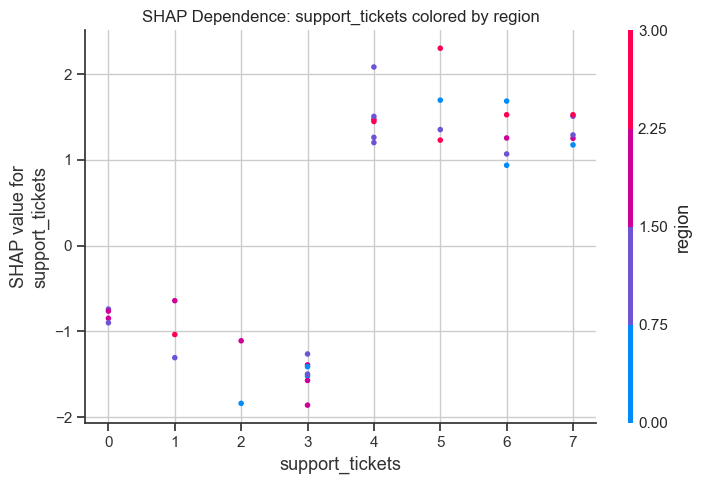

In [45]:
if len(top2) >= 2:
    try:
        inter_explainer = shap.TreeExplainer(model)
        inter_vals = inter_explainer.shap_interaction_values(X_inter)
        if isinstance(inter_vals, list):
            inter_vals = inter_vals[1] if len(inter_vals) > 1 else inter_vals[0]

        interaction_strength = np.abs(inter_vals[:, i1, i2]).mean()
        print(f'SHAP mean |interaction| between {f1} and {f2}: {interaction_strength:.5f}')

        # Dependence plot: x-axis is f1, color encodes f2 to reveal interaction pattern.
        shap.dependence_plot(
            i1,
            inter_explainer.shap_values(X_inter),
            X_inter,
            feature_names=feature_names,
            interaction_index=i2,
            show=False
        )
        plt.title(f'SHAP Dependence: {f1} colored by {f2}')
        plt.tight_layout()
        plt.show()
        interaction_ok = True
    except Exception as e:
        print('SHAP interaction computation failed, using fallback heatmap:', str(e))

In [46]:
if len(top2) >= 2 and not interaction_ok:
    # Fallback: approximate interaction with a binned risk heatmap.
    temp = pd.DataFrame({
        f1: X_val_t[:, i1],
        f2: X_val_t[:, i2],
        'risk': val_proba
    })
    temp['f1_bin'] = pd.qcut(temp[f1], q=5, duplicates='drop')
    temp['f2_bin'] = pd.qcut(temp[f2], q=5, duplicates='drop')
    heat = temp.pivot_table(index='f1_bin', columns='f2_bin', values='risk', aggfunc='mean')
    plt.figure(figsize=(7, 5))
    sns.heatmap(heat, cmap='viridis')
    plt.title(f'Predicted Risk Heatmap: {f1} x {f2}')
    plt.xlabel(f2)
    plt.ylabel(f1)
    plt.tight_layout()
    plt.show()

## 13) Slicing Analysis (Mini Audit)

Check whether model quality varies across groups. This is the core idea of milestone M4.

In [47]:
# Candidate subgroup columns ordered by preference for this dataset.
slice_candidates = ['region', 'plan_type', 'auto_pay', 'home_ownership', 'purpose', 'grade', 'sub_grade', 'emp_length', 'sex', 'gender', 'race']
slice_col = None
for c in slice_candidates:
    if c in X_val.columns:
        slice_col = c
        break

if slice_col is None:
    raise ValueError('No subgroup column found for slicing. Expected one of: ' + ', '.join(slice_candidates))

# Build subgroup evaluation table with labels and predicted probabilities.
tmp = pd.DataFrame({
    'group': X_val[slice_col].astype(str).fillna('missing'),
    'y_true': y_val.values,
    'y_prob': val_proba
})
tmp['y_pred'] = (tmp['y_prob'] >= 0.5).astype(int)

In [48]:
rows = []
min_group_size = 5
for g, part in tmp.groupby('group'):
    # Skip tiny groups because their metrics are unstable.
    if len(part) < min_group_size:
        continue
    auc = roc_auc_score(part['y_true'], part['y_prob']) if part['y_true'].nunique() > 1 else np.nan
    f1 = f1_score(part['y_true'], part['y_pred']) if part['y_true'].nunique() > 1 else np.nan
    pos_rate = part['y_true'].mean()
    rows.append({'group': g, 'n': len(part), 'positive_rate': pos_rate, 'auc': auc, 'f1': f1})

if not rows:
    print(f'No slice groups had at least {min_group_size} rows.')
else:
    slice_report = pd.DataFrame(rows).sort_values(['f1', 'auc'], na_position='last')
    print('Slice column used:', slice_col)
    display(slice_report.head(15))

Slice column used: region


,group,n,positive_rate,auc,f1
0,atlantic,7,0.571429,0.75,0.333333
2,pacific,9,0.333333,0.50,0.400000
1,central,13,0.230769,0.70,0.400000
3,prairies,7,0.428571,0.25,0.444444


## 14) Final Test Snapshot

This is a basic one-pass test check. In the project workbook, threshold and reporting are more strict.

In [ ]:
# Final test pass: evaluate with a fixed threshold to avoid tuning on test data.
test_proba = model.predict_proba(X_test_t)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

print('Test ROC-AUC:', round(roc_auc_score(y_test, test_proba), 4))
print('Test F1 (0.5 threshold):', round(f1_score(y_test, test_pred), 4))
print('\nClassification report (test):')
print(classification_report(y_test, test_pred, digits=3))

# Confusion matrix helps connect model quality to operational error types.
cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(cm, index=['actual_0', 'actual_1'], columns=['pred_0', 'pred_1'])
display(cm_df)

Test ROC-AUC: 0.7023
Test F1 (0.5 threshold): 0.381

Classification report (test):
              precision    recall  f1-score   support

           0      0.679     0.826     0.745        23
           1      0.500     0.308     0.381        13

    accuracy                          0.639        36
   macro avg      0.589     0.567     0.563        36
weighted avg      0.614     0.639     0.614        36



,pred_0,pred_1
actual_0,19,4
actual_1,9,4


## 15) What Students Should Learn from This Tutorial

1. A strong model is the start, not the end.
2. Local explanations reveal why specific cases fail.
3. Global views reveal hidden model rules and interactions.
4. Slicing analysis can expose concentrated risk across groups.
5. Good audit reports propose practical fixes, not just charts.

Next step: move to the project workbook and complete milestones M1 to M4.